✅ Iris data loaded successfully!


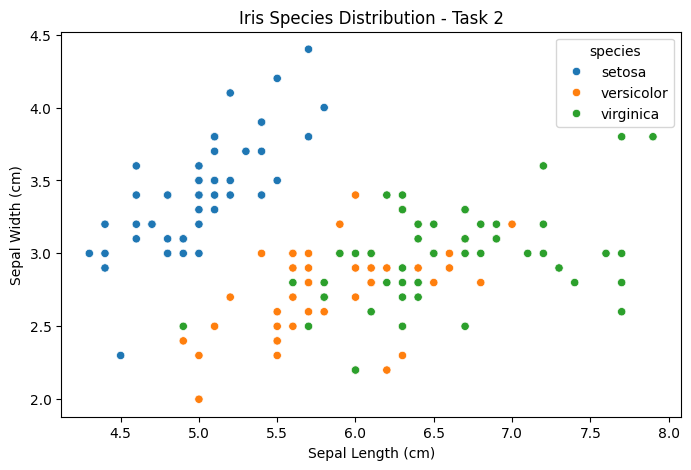


✅ House data loaded successfully!
✅ Task 1: Cleaning applied successfully!

--- Cleaned House Data Preview (first 5 rows) ---


/tmp/ipykernel_13906/4177247225.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_house = pd.read_csv('/house.csv', header=None, delim_whitespace=True)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- TASK 2: EDA ---
# Using the provided '1) iris.csv' file.
try:
    df_iris = pd.read_csv('/1) iris.csv')
    print("✅ Iris data loaded successfully!")

    # Create the chart using Iris dataset columns (corrected column names)
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df_iris, x='sepal_length', y='sepal_width', hue='species')
    plt.title("Iris Species Distribution - Task 2")
    plt.xlabel("Sepal Length (cm)")
    plt.ylabel("Sepal Width (cm)")
    plt.show()
except Exception as e:
    print(f"❌ An error occurred during EDA with iris.csv: {e}")

# --- TASK 1: CLEANING ---
# Using the provided '/house.csv' file.
try:
    # Load the CSV without a header to correctly assign column names
    df_house = pd.read_csv('/house.csv', header=None, delim_whitespace=True)
    print("\n✅ House data loaded successfully!")

    # Define the column names for the Boston Housing dataset
    column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

    # Assign the column names to the DataFrame
    df_house.columns = column_names

    df_house.drop_duplicates(inplace=True)
    df_house.fillna(df_house.mean(numeric_only=True), inplace=True)
    print("✅ Task 1: Cleaning applied successfully!")
    print("\n--- Cleaned House Data Preview (first 5 rows) ---")
    display(df_house.head())
except Exception as e:
    print(f"❌ An error occurred during Cleaning with house.csv: {e}")

### Iris Dataset - Additional EDA

#### Summary Statistics

In [21]:
print('--- Iris DataFrame Summary Statistics ---')
print(df_iris.describe())

print('\n--- Iris DataFrame Mode ---')
print(df_iris.mode(numeric_only=True))

--- Iris DataFrame Summary Statistics ---
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

--- Iris DataFrame Mode ---
   sepal_length  sepal_width  petal_length  petal_width
0           5.0          3.0           1.5          0.2


#### Distribution of Features (Histograms)

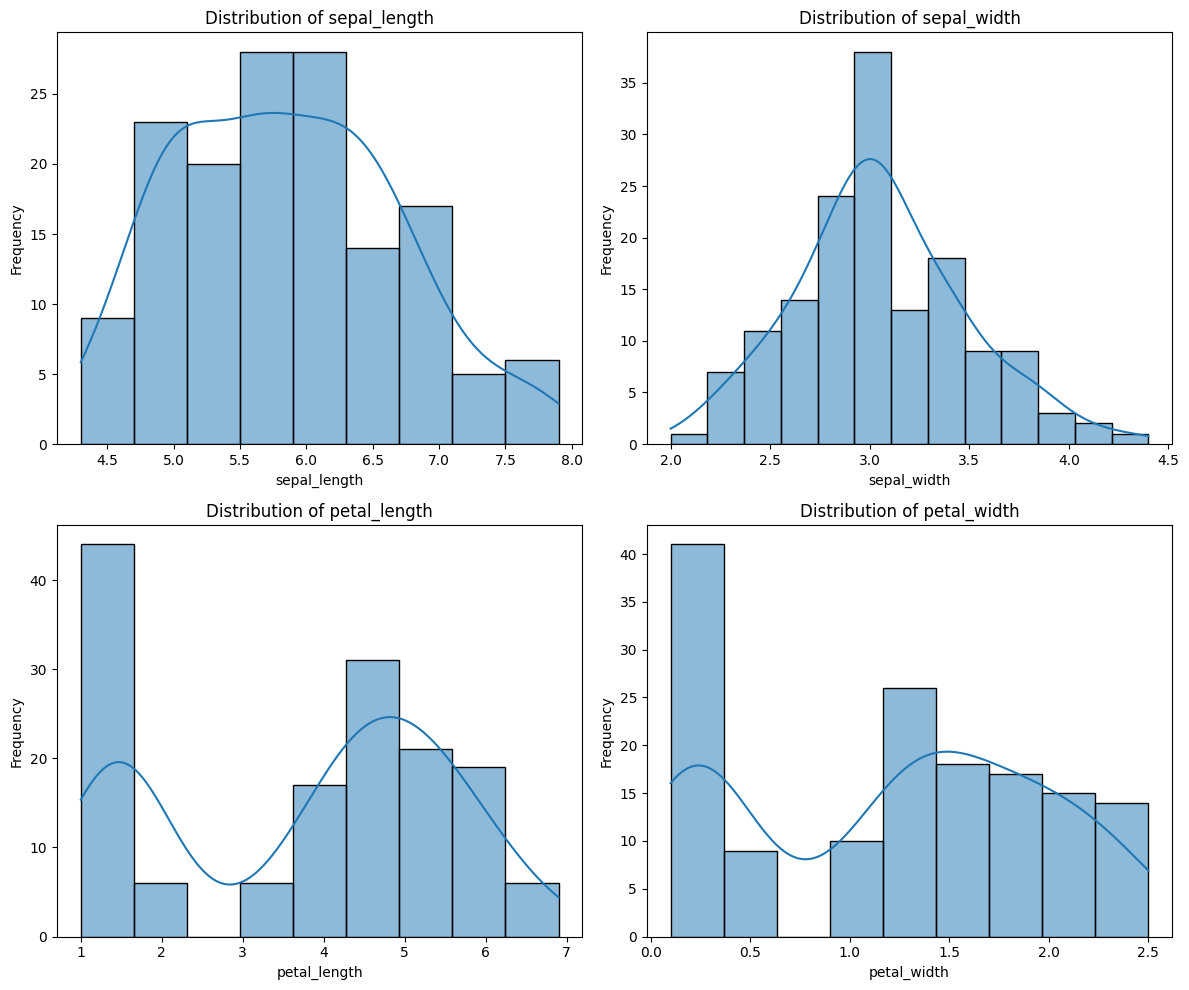

In [22]:
plt.figure(figsize=(12, 10))
for i, column in enumerate(df_iris.select_dtypes(include='number').columns):
    plt.subplot(2, 2, i + 1) # Arrange in a 2x2 grid
    sns.histplot(df_iris[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Feature Distribution by Species (Boxplots)

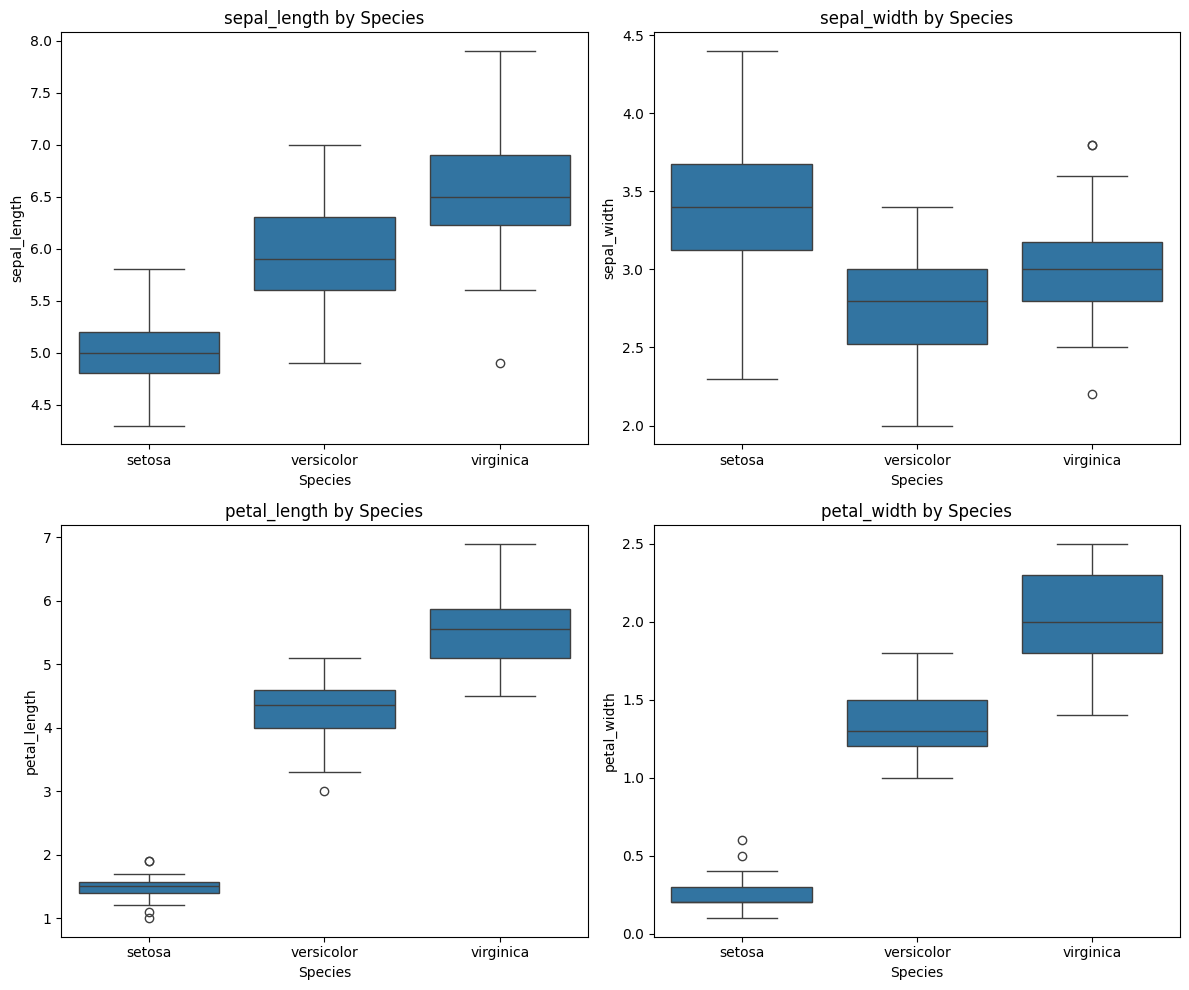

In [23]:
plt.figure(figsize=(12, 10))
for i, column in enumerate(df_iris.select_dtypes(include='number').columns):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df_iris, x='species', y=column)
    plt.title(f'{column} by Species')
    plt.xlabel('Species')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

#### Correlation Analysis (Heatmap)

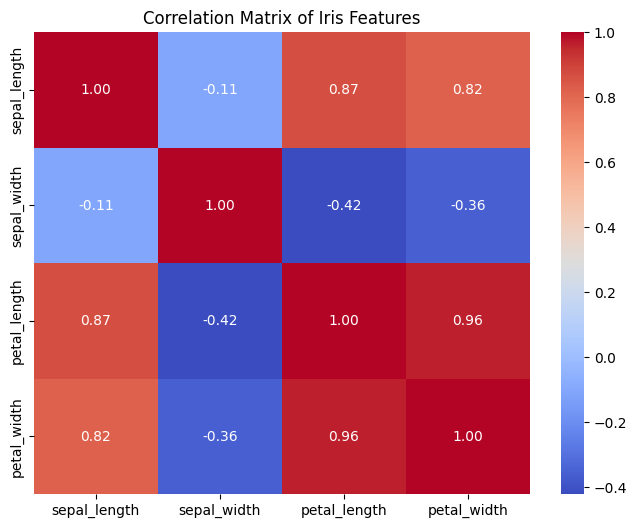

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_iris.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Iris Features')
plt.show()